# Imports

In [12]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%reload_ext autoreload
%autoreload 2

import sys
import random
import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import rasterio
import numpy as np
import pandas as pd
import matplotlib.cm as cm 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from collections import Counter
from difflib import SequenceMatcher
import random

import graph_manager
from graph_manager import GraphManager
import plotting

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
    "access", "width", "name", "name:en", "bicycle", "cycleway"]

SEED = 72
SAMPLE_K = 1000

# Network setup

In [13]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
LOCATION = "Malta (island)"

my_graph = GraphManager(LOCATION)


Loading OSM networks for Malta (island)...
['residential', 'residential']
['trunk', 'trunk']
['trunk', 'trunk']
['trunk', 'trunk']
['residential', 'residential']
['service', 'residential']
['non_motorised', 'residential', 'track']
['residential', 'track']
['residential', 'tertiary']
['residential', 'tertiary']
['service', 'tertiary']
['residential', 'residential']
['service', 'residential']
['non_motorised', 'residential']
['residential', 'residential']
['residential', 'residential']
['non_motorised', 'residential']
['non_motorised', 'track']
['residential', 'track']
['residential', 'track']
['residential', 'residential']
['residential', 'residential']
['residential', 'residential']
['residential', 'track']
['track', 'residential']
['non_motorised', 'residential']
['track', 'residential']
['trunk', 'trunk']
['service', 'non_motorised']
['service', 'residential']
['non_motorised', 'residential']
['non_motorised', 'residential']
['residential', 'track']
['service', 'track']
['residential

## Road type classification

In [ ]:
my_graph.summarise_road_type_stats(my_graph.G_master)

hi
Highway type counts:
residential: 38804
service: 15898
track: 11085
tertiary: 6155
secondary: 5313
non_motorised: 3297
trunk: 2076
primary: 1991
cycleway: 307
-------
bikeway classification type counts:
None: 82344
yes: 2196
designated: 324
no: 45
permissive: 14
private: 3
------
cycleway type counts:
None: 84644
no: 193
shared: 30
track: 23
shared_lane: 14
lane: 14
crossing: 8


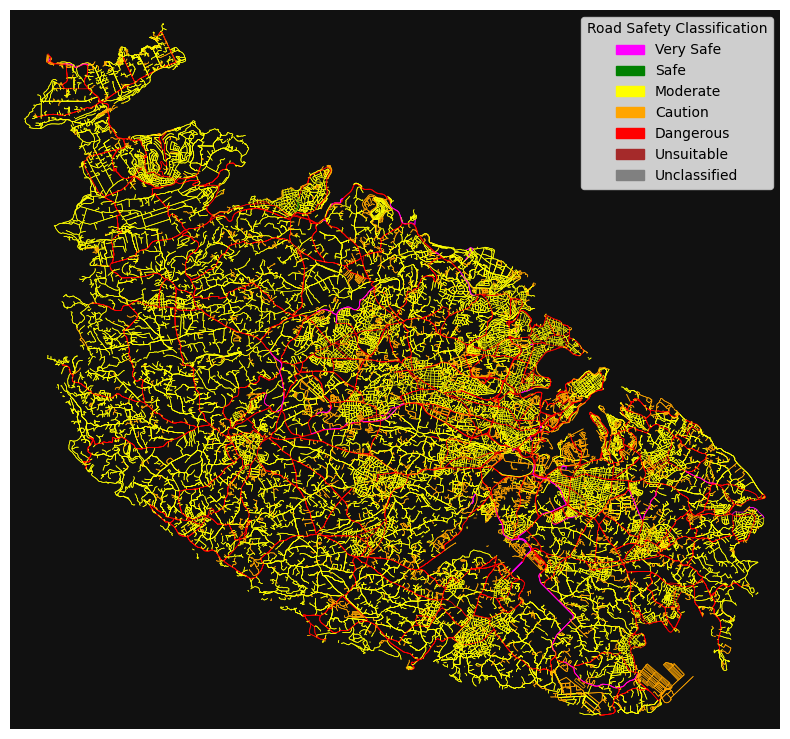

In [15]:
plotting.plot_road_classification(my_graph.G_master)

## Topology

In [16]:
ox.settings.elevation_url_template = (
    "https://api.opentopodata.org/v1/eudem25m?locations={locations}"
)


G_bike = ox.add_node_elevations_google(G_bike, batch_size=100, pause=5)
G_bike = ox.elevation.add_edge_grades(G_bike, add_absolute=True)

Fetched elevations for 35507 / 35507 nodes


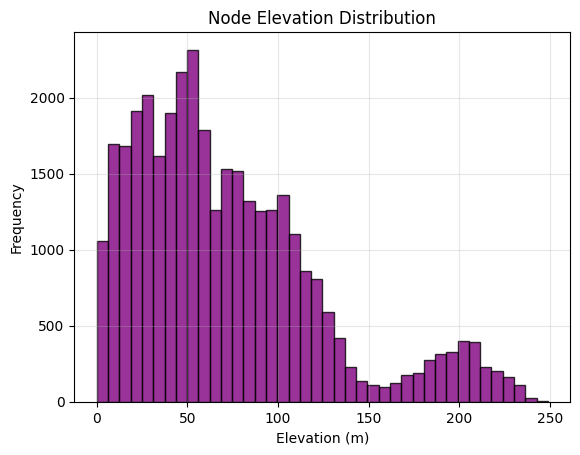

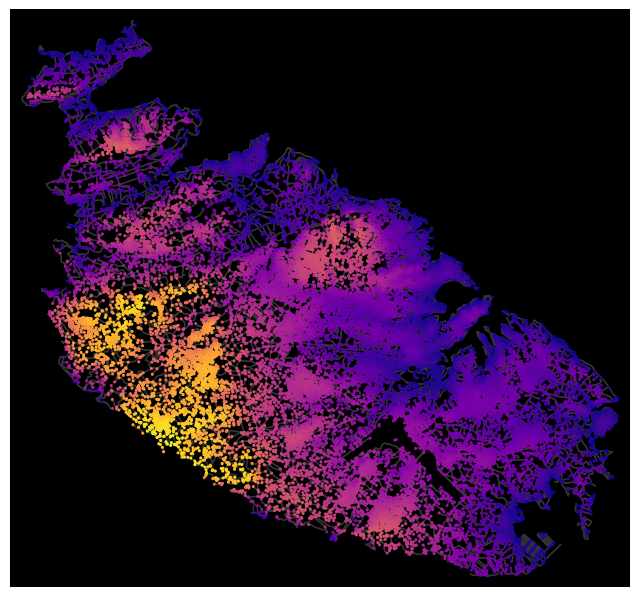

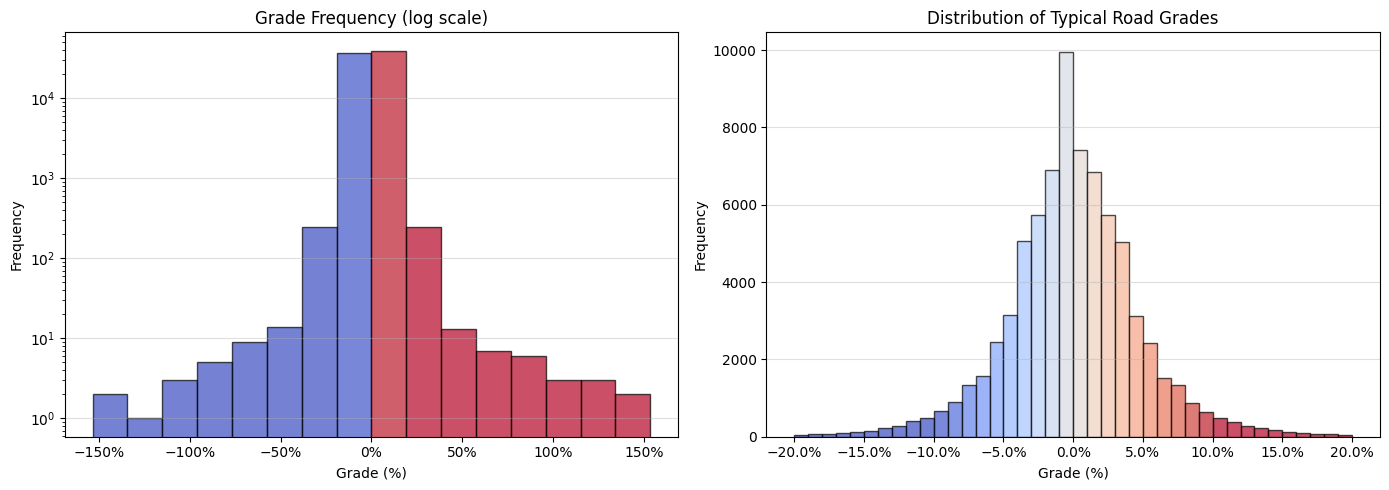

KeyboardInterrupt: 

In [17]:
plotting.plot_elevation(G_bike)
plotting.plot_grades(G_bike)

Replace NaN/missing elevations with the median

Iteration 1: imputed 379 nodes
Iteration 2: imputed 117 nodes
Iteration 3: imputed 29 nodes
Iteration 4: imputed 2 nodes
Iteration 5: imputed 0 nodes
Fetched elevations for 35507 / 35507 nodes


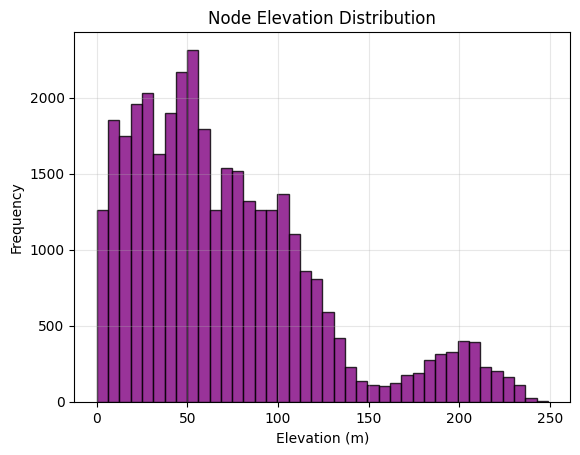

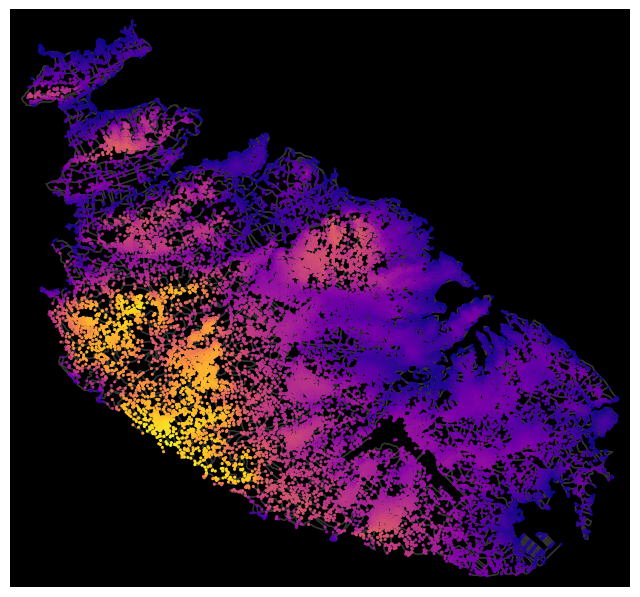

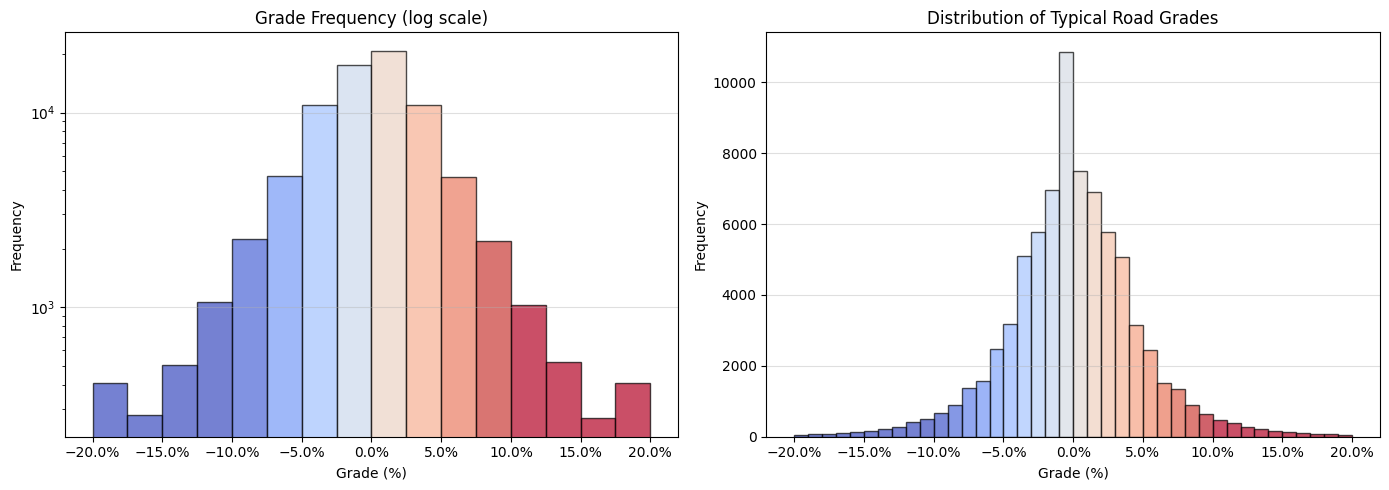

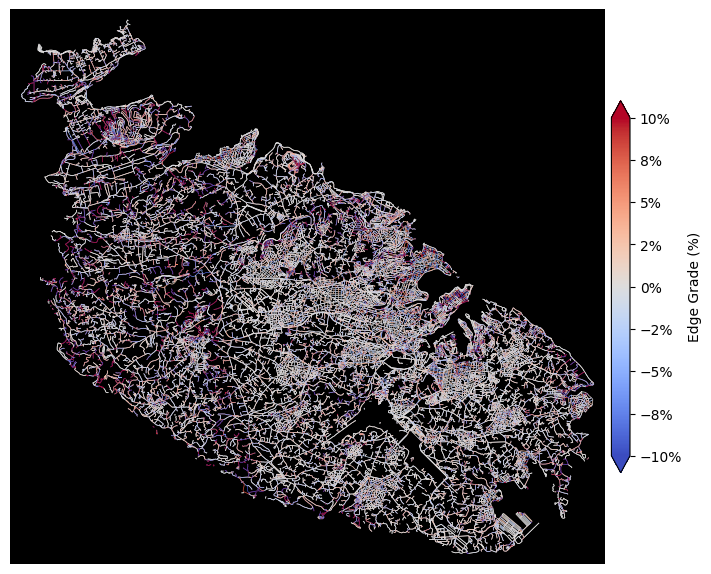

In [ ]:
max_iter = 10
for it in range(max_iter):
    changed = 0
    for node, data in G_bike.nodes(data=True):
        elev = data.get("elevation")
        if elev is None or np.isnan(elev):
            neigh_elevs = [
                G_bike.nodes[n].get("elevation")
                for n in G_bike.neighbors(node)
                if G_bike.nodes[n].get("elevation") is not None
                and not np.isnan(G_bike.nodes[n]["elevation"])
            ]
            if neigh_elevs:
                data["elevation"] = np.median(neigh_elevs)
                changed += 1
   
    print(f"Iteration {it+1}: imputed {changed} nodes")
    if changed == 0:
        break


G_bike = ox.elevation.add_edge_grades(G_bike, add_absolute=True)

for _,_, data in G_bike.edges(data=True):
    data["grade"] = float(np.clip(data["grade"], -0.2, 0.2))
    data["grade_abs"] = float(min(data["grade_abs"], 0.2))


plotting.plot_elevation(G_bike)
plotting.plot_grades(G_bike)

## Network statistics

In [ ]:
# what sized area does our network cover in square meters?
G_bike_proj = ox.projection.project_graph(G_bike) #convert lat/long coordinates into meters
bike_nodes_proj = ox.convert.graph_to_gdfs(G_bike_proj, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(G_bike_proj, area=graph_area_m, clean_int_tol=15)

In [ ]:
edge_keys = set()
for u,v,data in G_bike.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'width', 'reversed', 'access', 'name', 'cycleway', 'grade_abs', 'safety', 'risk_factor', 'tunnel', 'lanes', 'oneway', 'grade', 'bicycle', 'name:en', 'geometry', 'highway', 'bridge', 'length', 'osmid'}


## Road development context

In [ ]:
def fuzzy_match(name, targets, threshold=0.75):
    """Return True if name is similar to any target above threshold."""
    if not name:
        return False
    name = name.lower()
    for t in targets:
        if SequenceMatcher(None, name, t.lower()).ratio() >= threshold:
            print(f"matched '{name}' and '{t.lower()}'")
            return True
    return False

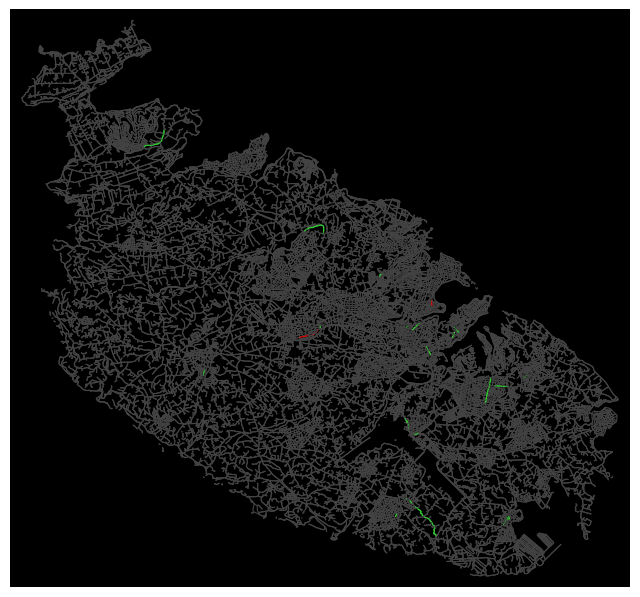


⚠️  Planned roads NOT found in OSM data:
  • Pjazza Tumas Dingli
  • Ix-Xatt iċ-Ċangatura
  • Triq il-Poetra Nazzjonali
  • Pjazzetta Anġlu Gatt
  • Misraħ Is-Saqqaja
  • Triq Mons. Mikiel Azzopardi
  • Misraħ Ħal Kirkop
  • Misraħ Santa Maria

⚠️  Recently constructed roads NOT found in OSM data:
  • L-Imdina road
  • Il-Konvoj ta' Santa Marija Street
  • Il-Belt Valletta Road
  • Manwel Dimech Street
  • Paola Road
  • Anton Buttigieg Road
  • Il-Hamsa u Ghoxrin ta' Novembru Avenue
  • Fisher Street
  • Sant' Anton Street
  • Cipru Street
  • Gibiltá Street
  • Il-Libja Street
  • Il-Marokk Street
  • Korfu Street
  • L-Argentina Street
  • L-Ingilterra Street
  • Ic-Cili Street
  • Il-Brazil Street
  • Il-Mithna Street
  • Spanja Street
  • It-Tuffieh Street


In [ ]:
planned_bike_construction = [
    "Triq Hompesch",
    "Triq Oscar Zammit",
    "Pjazza Tumas Dingli",
    "Triq Emvin Cremona",
    "Ix-Xatt iċ-Ċangatura",
    "Triq il-Poetra Nazzjonali",
    "Triq Selmun",
    "Pjazzetta Anġlu Gatt",
    "Triq John Adye",
    "Misraħ Is-Saqqaja",
    "Misraħ il-Knisja",
    "Triq Mons. Mikiel Azzopardi",
    "Triq San Tumas",
    "Misraħ Ħal Kirkop",
    "Misraħ Santa Maria",
]

recently_constructed = [
    "Triq iż-Żagħfran",
    "Triq in-Nutar Żarb",
    "L-Imdina road",  # partial match ok
    "Il-Konvoj ta' Santa Marija Street",
    "Il-Belt Valletta Road",
    "Manwel Dimech Street",
    "Abate Rigord Street",
    "Paola Road",
    "Anton Buttigieg Road",
    "Il-Hamsa u Ghoxrin ta' Novembru Avenue",
    "Fisher Street",
    "Sant' Anton Street",
    "Cipru Street",
    "Gibiltá Street",
    "Il-Libja Street",
    "Il-Marokk Street",
    "Korfu Street",
    "L-Argentina Street",
    "L-Ingilterra Street",
    "Ic-Cili Street",
    "Il-Brazil Street",
    "Il-Mithna Street",
    "Spanja Street",
    "It-Tuffieh Street",
]

edge_colors = []
found_green, found_red = set(), set()

#NOTE through testing of a typical example, this had a ratio of 0.68
# match = SequenceMatcher(None, "Triq Manwel Dimech", "Manwel Dimech Street").ratio()
threshold = 0.68  # adjust sensitivity (0.7–0.8 usually good)

for u, v, k, data in G_bike.edges(keys=True, data=True):
    name = data.get("name", "")
    en_name = data.get("name:en", "")
    color = "#444444"  # default gray

    # Collect both 'name' and 'name:en'
    raw_names = []
    for val in (name, en_name):
        if isinstance(val, list):
            raw_names.extend(val)
        elif val:
            raw_names.append(val)

    if not raw_names:
        edge_colors.append(color)
        continue

    road_names = [str(n).lower() for n in raw_names]  # combined names


    # Check each category
    if any(any(target.lower() in n for n in road_names) for target in planned_bike_construction):
        color = "limegreen"
        found_green.update(road_names)
    elif any(any(target.lower() in n for n in road_names) for target in recently_constructed):
        color = "red"
        found_red.update(road_names)

    edge_colors.append(color)


fig, ax = ox.plot.plot_graph(
    G_bike,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=0.8,
    bgcolor="k",
    show=True
)


found_green_normalized = {n.lower() for n in found_green}
found_red_normalized = {n.lower() for n in found_red}

not_found_green = [
    r for r in planned_bike_construction if r.lower() not in found_green_normalized
]
not_found_red = [
    r for r in recently_constructed if r.lower() not in found_red_normalized
]

if not_found_green:
    print("\n⚠️  Planned roads NOT found in OSM data:")
    for r in not_found_green:
        print("  •", r)

if not_found_red:
    print("\n⚠️  Recently constructed roads NOT found in OSM data:")
    for r in not_found_red:
        print("  •", r)

# Topological Metrics

Evaluating how good a network is

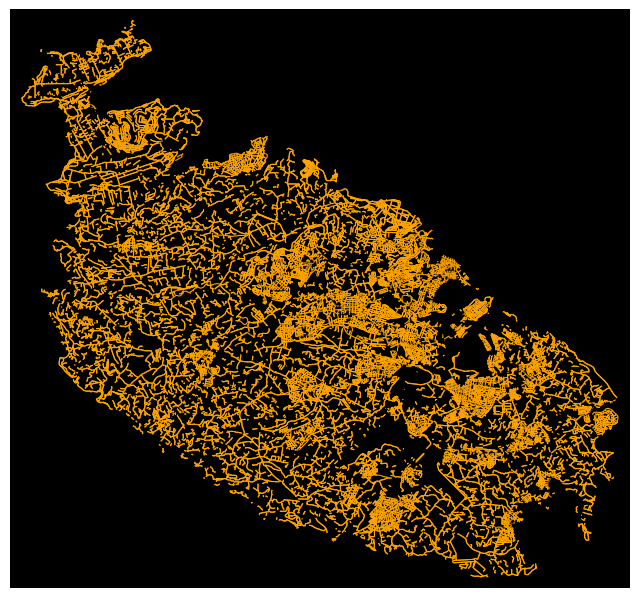

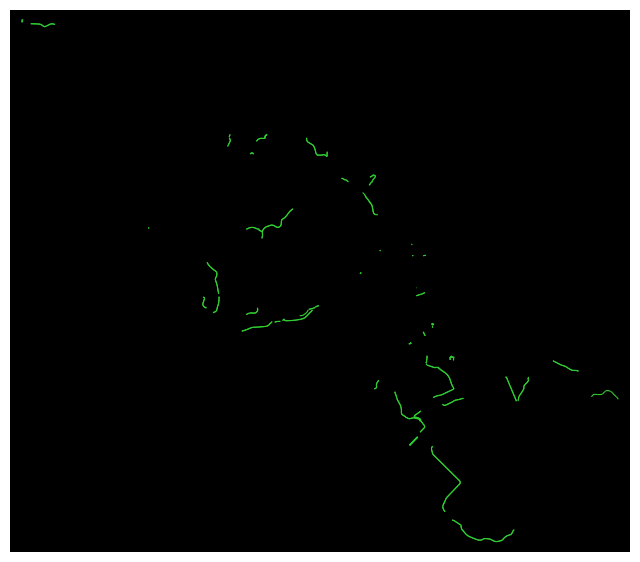

In [ ]:
protected_class = {"very_safe", "safe"}
bikeable_class = protected_class.union({"moderate"})

G_bikeable = graph_preprocessing.gen_safety_subgraph(G_bike,bikeable_class)
G_protected = graph_preprocessing.gen_safety_subgraph(G_bike,protected_class)


fig, ax = ox.plot_graph(
    G_bikeable,
    node_size=0,
    edge_color="orange",
    edge_linewidth=0.8,
    bgcolor="k"
)

fig, ax = ox.plot_graph(
    G_protected,
    node_size=0,
    edge_color="limegreen",
    edge_linewidth=0.8,
    bgcolor="k"
)

In [ ]:
# Connectedness - describing whether the network forms a single, navigable system or remains fragmented into multiple component
def calc_connectedness(G:MultiDiGraph, G_lcc:MultiDiGraph) -> dict:
    num_components = nx.number_strongly_connected_components(G)
    lcc_length = float(sum(d.get("length", 0) for _, _, d in G_lcc.edges(data=True)))

    return {
        "num_components": num_components,
        "lcc_length": lcc_length,
    }


"""def calc_directness(Gb_lcc:MultiDiGraph, G_drive:MultiDiGraph, k = SAMPLE_K, seed=SEED):
    #TODO update when I actually have OD matrix data
    rng = random.Random(seed)

    nodes_b = list(Gb_lcc.nodes())
    if len(nodes_b) < 2:
        raise ValueError("Bike LCC has fewer than 2 nodes.")
    K_eff = min(k, len(nodes_b) * 5)  # keep reasonable number of pairs
    rng.seed(seed)
    ods = []
    while len(ods) < K_eff:
        o = rng.choice(nodes_b)
        d = rng.choice(nodes_b)
        if o != d:
            ods.append((o, d))
            
    pass"""

def calc_centrality(G_lcc:MultiDiGraph, k=SAMPLE_K, seed = SEED) -> dict:
    """Calculate comprehensive centrality metrics for cycling network assessment"""
    #NOTE full centrality is O(n^3), k is instead used to approximate

    num_nodes = len(G_lcc.nodes)
    k_eff = min(k, num_nodes)
    
    # Edge betweenness centrality - connectors for network resilience
    edge_between_cent = nx.edge_betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_edge_between_cent = float(np.mean(list(edge_between_cent.values())))

    # betweenness centrality - measures how frequently a link lies on the shortest paths between all node pair
    node_between_cent = nx.betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_node_between_cent = float(np.mean(list(node_between_cent.values())))

    #closeness_centrality - how close all other nodes are 
    node_close_cent = nx.closeness_centrality(G_lcc, distance="length")
    mean_node_close_cent = float(np.mean(list(node_close_cent.values())))

    degrees = [d for _, d in G_lcc.degree()]
    mean_degree = float(np.mean(degrees))
        
    return {
        "mean_edge_betweenness": mean_edge_between_cent,
        "mean_node_betweenness": mean_node_between_cent,
        "mean_node_closeness": mean_node_close_cent,
        "mean_degree": mean_degree,
    }


def network_evaluation(G:MultiDiGraph) -> dict:
    G_lcc = ox.truncate.largest_component(G, strongly=True) #NOTE strongly connected true since roads cycle infrastructure is directional

    connectedness = calc_connectedness(G, G_lcc)
    centrality  = calc_centrality(G_lcc)
    results = {**connectedness, **centrality}
    return results

In [ ]:
# Directness - measures how efficiently users can travel between two point

# Centrality
network_evaluation(G_protected)
## Degree - number of connections per node

{'num_components': 75,
 'lcc_length': 4501.734357236379,
 'mean_edge_betweenness': 0.18421052631578944,
 'mean_node_betweenness': 0.33333333333333337,
 'mean_node_closeness': 0.0013893730063892743,
 'mean_degree': 3.8}

# Optimisation Approaches 

In [ ]:
def add_protected_cycle_lane(G_bike, G_protected, G_car):


## Heuristic Approaches

Centrality - betweeness and closeness

In [ ]:
def heuristic(G:MultiDiGraph):
    edges_between_cent = nx.edge_betweenness_centrality(G, weight="length", normalized=True)
    max_between_cent_edge = max(edges_between_cent, key=edges_between_cent.get)

## LP and MILP

$$\text{bike\_cost} = \text{length} \times (\alpha\text{gradient} + \beta\text{risk})$$

In [ ]:
for u,v,data in G_bike.edges(data=True):
    service = data.get("service", None)
    if service:
        highway = data["highway"]
        print(f"highway: {highway} \t service:{service}")


NameError: name 'G_bike' is not defined

In [ ]:
#Prob all wrong tbh
"""
u - Source node ID (starting point of the edge)
v - Target node ID (ending point of the edge)
k - Edge key (for multigraphs where multiple edges can exist between the same nodes)
data - Dictionary containing all the edge attributes/properties"""
#Since continuity will be used a global evaluation metric there is no need to have it be a weight in the pair wise edges

def calc_bike_cost(G_bike, alpha, beta):
    # Project the graph for meters distances instead of angles
    G_bike_proj = ox.projection.project_graph(G_bike)

    for u, v, k, data in G_bike_proj.edges(keys=True, data=True):
        #alpha*data["grade_abs"]
        #NOTE absolute length was used instead of normalised length to keep the true magnitude ensures realistic, additive path costs rather than distorting them through arbitrary scaling.
        data["bike_cost"] = data["length"] * (beta*data["risk_factor"])
        pass


# First calculate bike costs
calc_bike_cost(G_bike, alpha=0.1, beta=1.0)  # Adjust alpha/beta values as needed


what_im_plotting = "bike_cost"

# Get edge colors based on bike_cost
edge_colors = ox.plot.get_edge_colors_by_attr(G_bike, what_im_plotting, cmap="viridis")
grade_abs_values = [data.get(what_im_plotting, 0) for u, v, k, data in G_bike.edges(keys=True, data=True) if data.get(what_im_plotting) is not None]
min_grade = min(grade_abs_values)
max_grade = max(grade_abs_values)

# Plot the network
fig, ax = ox.plot.plot_graph(G_bike, node_size=0, edge_color=edge_colors, edge_linewidth=0.5, show=False, close=False)
# Create and add colorbar
sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=min_grade, vmax=max_grade))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label(what_im_plotting, rotation=270, labelpad=20)
plt.tight_layout()
plt.show()

KeyError: 'risk_factor'

In [ ]:
edges = ox.convert.graph_to_gdfs(G_bike, nodes=False)
edges.groupby("risk_factor")["bike_cost"].mean()